IMPORTING THE NECESSARY LIBRARIES

In [31]:
import pandas as pd
import numpy as np

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


LOADING THE DATASET

In [32]:
df=pd.read_csv('bbc_text_cls.csv')

EXPLORING THE DATA

In [33]:
print(df.head())
print('-------------------------------------------------------------')
print(df.columns)
print('-------------------------------------------------------------')
print(df.info())
print('-------------------------------------------------------------')
print(df.shape)

                                                text    labels
0  Ad sales boost Time Warner profit\n\nQuarterly...  business
1  Dollar gains on Greenspan speech\n\nThe dollar...  business
2  Yukos unit buyer faces loan claim\n\nThe owner...  business
3  High fuel prices hit BA's profits\n\nBritish A...  business
4  Pernod takeover talk lifts Domecq\n\nShares in...  business
-------------------------------------------------------------
Index(['text', 'labels'], dtype='object')
-------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2225 non-null   object
 1   labels  2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB
None
-------------------------------------------------------------
(2225, 2)


CHECKING FOR MISSING VALUES

In [34]:
df.isnull().sum()

,0
text,0
labels,0


DOING PREPROCESSING

In [35]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

APPLYING PREPROCESSING

In [36]:
df['clean_text'] = df['text'].apply(preprocess_text)

print(df[['text','clean_text']].head())

                                                text  \
0  Ad sales boost Time Warner profit\n\nQuarterly...   
1  Dollar gains on Greenspan speech\n\nThe dollar...   
2  Yukos unit buyer faces loan claim\n\nThe owner...   
3  High fuel prices hit BA's profits\n\nBritish A...   
4  Pernod takeover talk lifts Domecq\n\nShares in...   

                                          clean_text  
0  ad sale boost time warner profit quarterly pro...  
1  dollar gain greenspan speech dollar hit highes...  
2  yukos unit buyer face loan claim owner embattl...  
3  high fuel price hit ba profit british airway b...  
4  pernod takeover talk lift domecq share uk drin...  


LABEL ENCODING

In [37]:
encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(df['labels'])

print("Label Mapping:")

for label, value in zip(encoder.classes_, range(len(encoder.classes_))):
    print(f"{label} --> {value}")

Label Mapping:
business --> 0
entertainment --> 1
politics --> 2
sport --> 3
tech --> 4


TF-IDF

In [38]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['label_encoded']

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (2225, 5000)


SPLIT

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 1780
Testing Samples  : 445


BUILDING THE LOGISTIC MODEL

In [40]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


PREDICTON

In [41]:
y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


ACCURACY

In [42]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9707865168539326


CLASSIFICATION REPORT

In [43]:
print(classification_report(y_test,y_pred,target_names=encoder.classes_))

               precision    recall  f1-score   support

     business       0.95      0.97      0.96       115
entertainment       0.99      0.96      0.97        72
     politics       0.95      0.97      0.96        76
        sport       1.00      0.99      1.00       102
         tech       0.97      0.96      0.97        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445



CONFUSION MATRIX

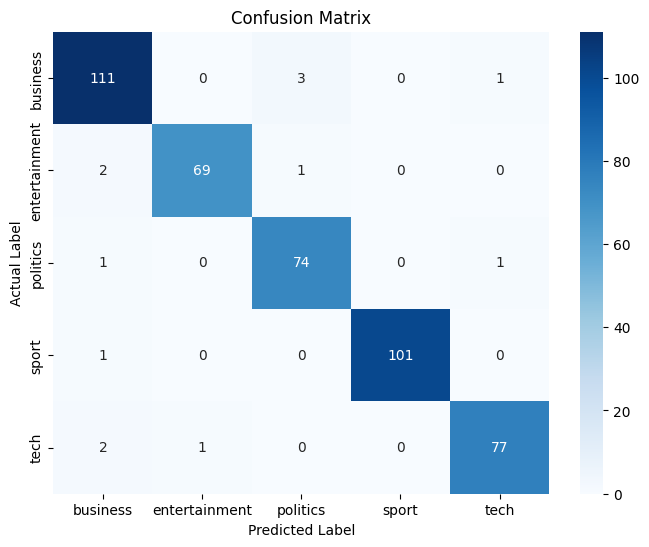

In [44]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()